In [91]:

import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
# 1. 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/csv/TSLA.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [94]:
# 필요한 컬럼만 선택 (Open, High, Low, Close)
data = df[['Open', 'High', 'Low', 'Close']].values

In [95]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [96]:
print("\n 결측값 확인:")
print(df.isnull().sum())


 결측값 확인:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [97]:
# 2. 정규화
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [98]:
window = 12  # 최근 12일 데이터로 다음날 예측
X, y = [], []
for i in range(len(data) - window):
    X.append(data[i:i+window])
    y.append(data[i+window])
X, y = np.array(X), np.array(y)


In [99]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [100]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (2355, 12, 4)
y_train shape: (2355, 4)


In [101]:
rnn_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window, 4)),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(4)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0037
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.5552e-05
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5894e-05
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1213e-05
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.4008e-06
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.9874e-06
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1337e-06
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0480e-06
Epoch 9/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.2919e-06
Epoch 10/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.4823e-06
Epoch 11/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.3152e-06
Epoch 12/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.2425e-06
Epoch 13/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.8259e-06
Epoch 14/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.9121e-06
Epoch 15/50
148

In [102]:
rnn_pred = rnn_model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


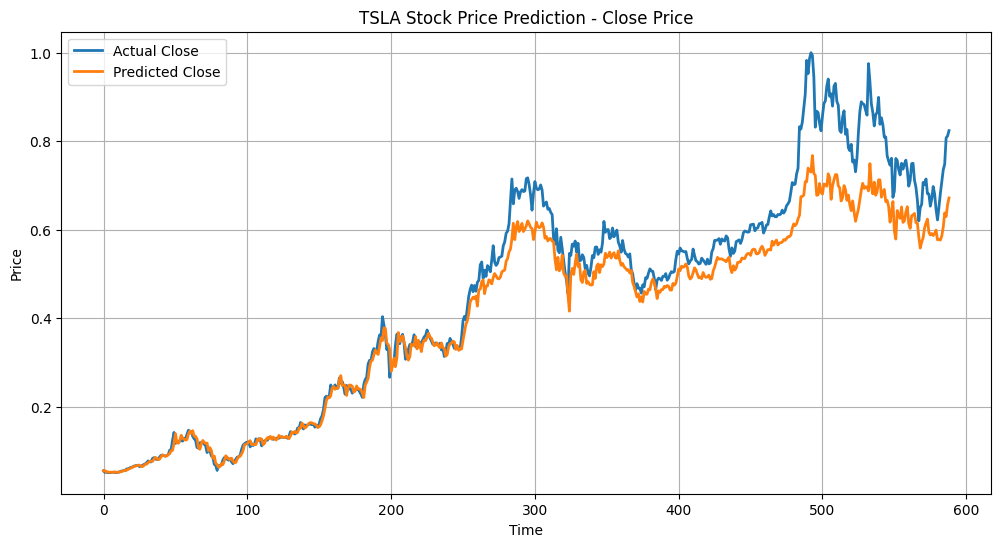

In [103]:
# 8. Close 가격 시각화
plt.figure(figsize=(12, 6))
plt.plot(y_test[:, 3], label='Actual Close', linewidth=2)
plt.plot(rnn_pred[:, 3], label='Predicted Close', linewidth=2)
plt.title('TSLA Stock Price Prediction - Close Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [104]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# 9. 평가 지표 (Close 가격 기준)
print("\n=== Close Price Prediction Metrics ===")
print("MSE:", mean_squared_error(y_test, rnn_pred))
print("MAE:", mean_absolute_error(y_test, rnn_pred))
print("R² score:", r2_score(y_test, rnn_pred))


=== Close Price Prediction Metrics ===
MSE: 0.003614327966521595
MAE: 0.0371457265542447
R² score: 0.945102334503775


In [105]:
# ---------------------------------------------------
# 6. LSTM 모델
# ---------------------------------------------------
lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(window, 4)),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(4)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.9917e-04
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.1883e-06
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.8736e-06
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.9434e-06
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.8193e-06
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.3124e-06
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.1971e-06
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.7740e-06
Epoch 9/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.9303e-06
Epoch 10/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.8344e-06
Epoch 11/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.1654e-06
Epoch 12/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.1784e-06
Epoch 13/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.0798e-06
Epoch 14/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3764e-06
Epoch 15/50

In [106]:

lstm_pred = lstm_model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


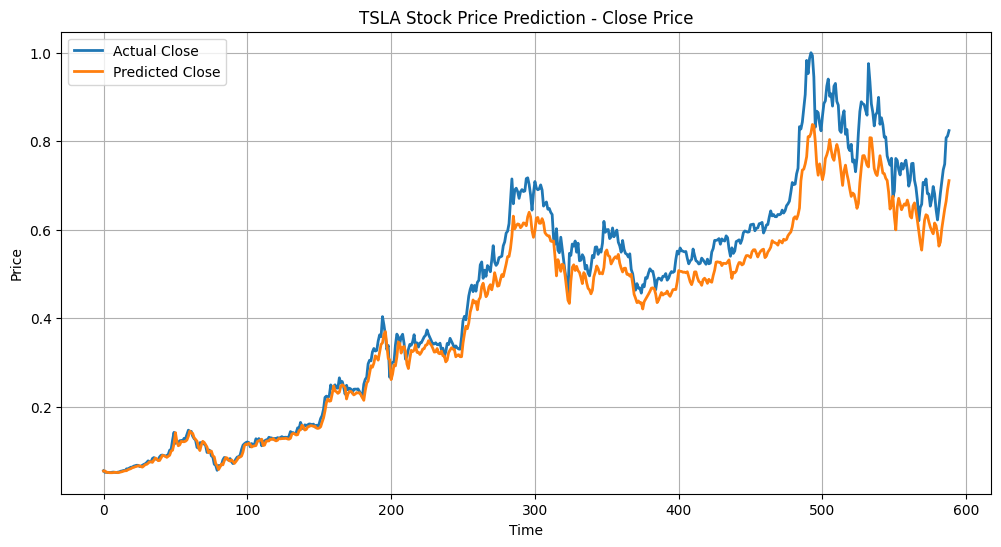

In [107]:
plt.figure(figsize=(12, 6))
plt.plot(y_test[:, 3], label='Actual Close', linewidth=2)
plt.plot(lstm_pred[:, 3], label='Predicted Close', linewidth=2)
plt.title('TSLA Stock Price Prediction - Close Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [108]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 9. 평가 지표 (Close 가격 기준)
print("\n=== Close Price Prediction Metrics ===")
print("MSE:", mean_squared_error(y_test, lstm_pred))
print("MAE:", mean_absolute_error(y_test, lstm_pred))
print("R² score:", r2_score(y_test, lstm_pred))


=== Close Price Prediction Metrics ===
MSE: 0.003506400675834983
MAE: 0.04330053729355498
R² score: 0.9471949839833645
